# E2.2 — Convergence Analysis (start-point ergodicity test)

Tests whether the diverse-start extended replicates of a system relax into the **same**
equilibrated ensemble, or stay trapped near their starting conformations. This is the
ergodicity check that decides whether the leaner campaign holds.

**Inputs.** All `trajectories_extended/{SYSTEM}_*ns_{start}_r*` runs found on disk.

**What it compares.** Radius of gyration is the primary coordinate — the starts differ on it by
construction, so its convergence is the direct ergodicity signal. Motif SASA is the reported
observable. For each it reports, on the equilibrated portion: the autocorrelation-corrected
mean ± CI (N_eff-based), a standardised mean difference z between starts, and the distribution
overlap coefficient.

> **Refactor note (E3.x handoff).** The autocorrelation / N_eff / CI routine and the pooled
> 7b routine are no longer defined inline here — they are imported from
> `convergence_stats.py` so that E3.x uses the identical code and obtains numerically
> identical CIs. The CI is a parametric, autocorrelation-corrected normal-approximation SE
> (`N_eff = N/tau_int`, `se = SD/sqrt(N_eff)`, `ci95 = 1.96*se`) — **not** a block-bootstrap.

## 1 — Imports
**Out:** namespace. Now also imports the shared `convergence_stats` module.

In [2]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import mdtraj as md
import matplotlib.pyplot as plt

# Shared, canonical convergence statistics (extracted verbatim from this notebook's
# former cells 3/6/7/7b). E3.x imports the same module -> identical CIs by construction.
import convergence_stats as cs
from convergence_stats import compute_stat, pairwise, pooled_stability, verdict

print(f"MDTraj {md.__version__}")
print(f"convergence_stats | dt_ps={cs.DT_PS} stride={cs.STRIDE} discard_ns={cs.DISCARD_NS} "
      f"tau_floor={cs.TAU_FLOOR} c={cs.DEFAULT_C}")

MDTraj 1.11.1
convergence_stats | dt_ps=10.0 stride=10 discard_ns=20.0 tau_floor=1.0 c=5.0


## 2 — Configuration
**Out:** parameters and verdict thresholds.

The sampling constants (`EQUIL_DISCARD_NS`, `STRIDE`, `SAVE_INTERVAL_PS`) are asserted equal to
the module's constants so the notebook and the shared routine cannot silently diverge.

In [3]:
SYSTEM = 'GGE_water'
EQUIL_DISCARD_NS = 20.0          # scaled to glyceline tau_int
STRIDE           = 10            # analyse every 10 ps (resolves ns correlations, keeps SASA tractable)
SAVE_INTERVAL_PS = 1.0

# Guard: the notebook's sampling constants must match the shared module's, or the
# imported estimator would be operating on a different convention than intended.
assert EQUIL_DISCARD_NS == cs.DISCARD_NS,     "EQUIL_DISCARD_NS != convergence_stats.DISCARD_NS"
assert STRIDE           == cs.STRIDE,          "STRIDE != convergence_stats.STRIDE"
assert SAVE_INTERVAL_PS == cs.SAVE_INTERVAL_PS,"SAVE_INTERVAL_PS != convergence_stats.SAVE_INTERVAL_PS"

Z_CONSISTENT = 2.0               # |z| below -> means consistent
Z_SEPARATED  = 3.0               # |z| above -> means clearly separated
OVL_GOOD     = 0.70              # overlap above -> distributions agree
OVL_POOR     = 0.50              # overlap below -> distributions separated

THREE_TO_ONE = {'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C','GLN':'Q','GLU':'E',
                'GLY':'G','HIS':'H','ILE':'I','LEU':'L','LYS':'K','MET':'M','PHE':'F',
                'PRO':'P','SER':'S','THR':'T','TRP':'W','TYR':'Y','VAL':'V'}

## 3 — Autocorrelation estimator *(now imported)*
The FFT/Sokal estimator (`autocorr_func_1d`, `integrated_time`) previously defined here is now
provided by `convergence_stats`. This cell only re-exports the names for any code below that
referenced them directly, and records the convention. **Out:** `integrated_time` (from module).

In [4]:
# Estimator now lives in convergence_stats (single source of truth for E2.x + E3.x).
from convergence_stats import autocorr_func_1d, integrated_time

# Convention (documented in the module docstring):
#   ACF: FFT-based, normalised to 1.0 at lag 0
#   tau_int: Sokal windowing c=5.0, floored at 1.0 (strided lags)
#   N_eff = N / tau_int ; se = SD(ddof=1)/sqrt(N_eff) ; ci95 = 1.96*se
print("integrated_time / autocorr_func_1d imported from convergence_stats")

integrated_time / autocorr_func_1d imported from convergence_stats


## 4 — Discover extended-campaign runs
Globs the extended trajectory tree for this system. **Out:** `RUNS` (label -> paths).

In [5]:
PROJECT_DIR = Path("~/des-peptide-study").expanduser()
PRMTOP      = next(p for p in (PROJECT_DIR/"systems"/SYSTEM/f"{SYSTEM}.prmtop",
                               PROJECT_DIR/"systems"/f"{SYSTEM}.prmtop") if p.exists())
EXT_DIR     = PROJECT_DIR / "extension" / "trajectories_extended"

pat = re.compile(rf"{re.escape(SYSTEM)}_(\d+)ns_(.+)_r(\d+)$")
RUNS = {}
for d in sorted(EXT_DIR.glob(f"{SYSTEM}_*")):
    m = pat.match(d.name)
    dcd = d / f"{d.name}.dcd"
    if m and dcd.exists():
        RUNS[m.group(2)] = {"tag": d.name, "dcd": dcd, "ns": int(m.group(1))}

print(f"{len(RUNS)} extended run(s) for {SYSTEM}:")
for label, r in RUNS.items():
    print(f"  {label:<9} {r['tag']} ({r['ns']} ns)")
assert len(RUNS) >= 2, "need at least two starts to test convergence" 

4 extended run(s) for GGE_water:
  compact   GGE_water_200ns_compact_r1 (200 ns)
  extended  GGE_water_200ns_extended_r1 (200 ns)
  mid       GGE_water_200ns_mid_r1 (200 ns)
  open      GGE_water_200ns_open_r1 (200 ns)


## 5 — Extract observables
Loads each run strided, computes peptide Rg and motif SASA per frame, and splits off the
equilibrated portion. **In:** `RUNS`. **Out:** `data` (label -> series).

The discard + stride happen here (`stride=STRIDE` in the load, `[n_equil:]` slice), so the
`data[label]['rg'|'sasa']` series are **already equilibrated and strided** — they are passed to
`compute_stat` as-is (do **not** call `convergence_stats.prepare_series` on them; that helper is
for E3.x code that builds its own raw series).

In [6]:
motif_seq = SYSTEM.split("_")[0]
dt_ps     = SAVE_INTERVAL_PS * STRIDE
n_equil   = int(EQUIL_DISCARD_NS * 1000.0 / dt_ps)
assert dt_ps == cs.DT_PS, "dt_ps != convergence_stats.DT_PS"

def observables(dcd):
    traj = md.load(str(dcd), top=str(PRMTOP), stride=STRIDE)
    sel = traj.topology.select("protein")
    if len(sel) == 0:
        sel = traj.topology.select("not (water or resname HOH WAT CHO CLA URE GOL NA CL Na+ Cl-)")
    prot = traj.atom_slice(sel)
    seq = "".join(THREE_TO_ONE.get(r.name, "X") for r in prot.topology.residues)
    pos = seq.find(motif_seq); idx = list(range(pos, pos + len(motif_seq)))
    sasa = md.shrake_rupley(prot, mode="residue")[:, idx].sum(axis=1)
    rg = md.compute_rg(prot)
    return rg, sasa

data = {}
for label, r in RUNS.items():
    print(f"  {label} ...", end=" ", flush=True)
    rg, sasa = observables(r["dcd"])
    data[label] = {"rg_full": rg, "sasa_full": sasa,
                   "rg": rg[n_equil:], "sasa": sasa[n_equil:]}
    print(f"{len(rg)} frames")
print("done")

  compact ... 20000 frames
  extended ... 20000 frames
  mid ... 20000 frames
  open ... 20000 frames
done


## 6 — Per-start statistics
Equilibrated mean, τ_int, N_eff, and N_eff-based 95% CI for each start and observable, via
`convergence_stats.compute_stat`. **Out:** `stats` table.

In [7]:
rows = []
for label in RUNS:
    for obs in ("rg", "sasa"):
        s = compute_stat(data[label][obs])       # was: stat(...)  — identical routine, now imported
        rows.append({"start": label, "observable": obs.upper(),
                     "mean": round(s["mean"], 4), "tau_int_ns": round(s["tau_int_ns"], 2),
                     "N_eff": round(s["N_eff"], 1), "ci95": round(s["ci95"], 4)})
        data[label].setdefault("stat", {})[obs] = s
stats = pd.DataFrame(rows)
print(stats.to_string(index=False))

   start observable   mean  tau_int_ns  N_eff   ci95
 compact         RG 0.6628       11.34   15.9 0.0402
 compact       SASA 2.3824       12.86   14.0 0.2064
extended         RG 0.7269        7.83   23.0 0.0373
extended       SASA 2.7884        5.66   31.8 0.1070
     mid         RG 0.6514        4.44   40.5 0.0178
     mid       SASA 2.2891        3.56   50.6 0.0880
    open         RG 0.7751        4.52   39.8 0.0311
    open       SASA 2.9003        2.99   60.3 0.0721


## 7 — Pairwise start comparison
Standardised mean difference z and distribution overlap for every pair of starts, via
`convergence_stats.pairwise`. **Out:** `comp` table.

In [8]:
comp = pairwise(data, list(RUNS))
print(comp.to_string(index=False))

               pair observable  delta_mean     z  overlap
compact vs extended         RG     -0.0641  2.29     0.69
compact vs extended       SASA     -0.4060  3.42     0.54
     compact vs mid         RG      0.0114  0.51     0.84
     compact vs mid       SASA      0.0934  0.82     0.87
    compact vs open         RG     -0.1123  4.33     0.54
    compact vs open       SASA     -0.5179  4.64     0.44
    extended vs mid         RG      0.0755  3.58     0.64
    extended vs mid       SASA      0.4993  7.07     0.43
   extended vs open         RG     -0.0482  1.95     0.77
   extended vs open       SASA     -0.1119  1.70     0.84
        mid vs open         RG     -0.1237  6.77     0.46
        mid vs open       SASA     -0.6112 10.53     0.32


## 7b — Pooled-ensemble stability
Pools the equilibrated series across all starts and reports the autocorrelation-corrected pooled
mean ± CI from the summed per-start N_eff, plus a leave-one-out table (a shift beyond the pooled
CI flags a dominating start). Now via `convergence_stats.pooled_stability`. **Out:** `pooled_stats`,
`loo`.

In [9]:
pooled_stats, loo = pooled_stability(data, list(RUNS))
print(pooled_stats.to_string(index=False)); print()
print(loo.to_string(index=False)); print()
for obs in ("RG", "SASA"):
    ci, mx, tag = verdict(pooled_stats, loo, obs)
    print(f"{obs}: max leave-one-out shift {mx:.4f} vs pooled CI {ci:.4f} -> {tag}")

observable  n_starts  pooled_mean  N_eff_pooled   ci95
        RG         4        0.704         119.2 0.0176
      SASA         4        2.590         156.7 0.0656

observable  dropped  mean_without   shift  shift_gt_ci
        RG  compact        0.7178  0.0137        False
        RG extended        0.6964 -0.0076        False
        RG      mid        0.7216  0.0176        False
        RG     open        0.6803 -0.0237         True
      SASA  compact        2.6593  0.0692         True
      SASA extended        2.5239 -0.0661         True
      SASA      mid        2.6904  0.1003         True
      SASA     open        2.4866 -0.1034         True

RG: max leave-one-out shift 0.0237 vs pooled CI 0.0176 -> DOMINATED by one start
SASA: max leave-one-out shift 0.1034 vs pooled CI 0.0656 -> DOMINATED by one start


## 8 — Distributions and cumulative-mean traces
Left: equilibrated Rg and SASA distributions per start. Right: cumulative mean from t=0 with the
equilibration cut marked. **Out:** figure. *(Unchanged from the original notebook.)*

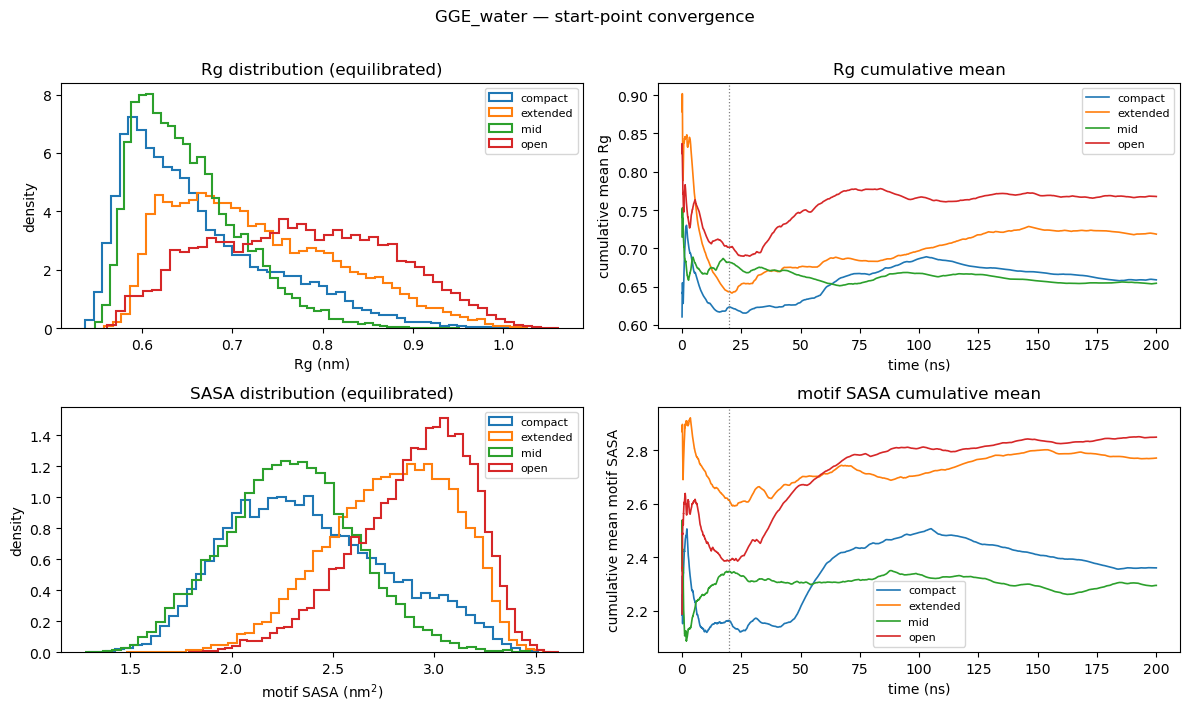

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(12, 7))
for label in RUNS:
    d = data[label]
    ax[0,0].hist(d["rg"], bins=50, density=True, histtype="step", lw=1.5, label=label)
    ax[1,0].hist(d["sasa"], bins=50, density=True, histtype="step", lw=1.5, label=label)
    for k, (obs, axc) in enumerate((("rg_full", ax[0,1]), ("sasa_full", ax[1,1]))):
        s = d[obs]; cum = np.cumsum(s) / np.arange(1, len(s) + 1)
        t = np.arange(len(s)) * dt_ps / 1000.0
        axc.plot(t, cum, lw=1.2, label=label)

ax[0,0].set_xlabel("Rg (nm)"); ax[0,0].set_ylabel("density"); ax[0,0].set_title("Rg distribution (equilibrated)")
ax[1,0].set_xlabel("motif SASA (nm$^2$)"); ax[1,0].set_ylabel("density"); ax[1,0].set_title("SASA distribution (equilibrated)")
for axc, name in ((ax[0,1], "Rg"), (ax[1,1], "motif SASA")):
    axc.axvline(EQUIL_DISCARD_NS, color="grey", ls=":", lw=0.9)
    axc.set_xlabel("time (ns)"); axc.set_ylabel(f"cumulative mean {name}")
    axc.set_title(f"{name} cumulative mean")
for a in ax.flat:
    a.legend(fontsize=8)
fig.suptitle(f"{SYSTEM} — start-point convergence", y=1.01)
fig.tight_layout()
OUT = PROJECT_DIR / "extension" / "analysis" / "convergence"
OUT.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT / f"{SYSTEM}_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

## 9 — Verdict
Applies the thresholds to the compact-vs-extended contrast (the designed pair). **Out:** verdict +
`convergence_summary_{SYSTEM}.csv`.

The primary CSV save (`comp`, the pairwise table) is preserved byte-for-byte from the original so
the regression diff against the committed summaries is exact. The 7b pooled/loo tables — which the
original notebook only printed, never saved — are additionally written to sidecar CSVs so E3.x has
a persisted reference for the pooled CIs.

In [11]:
def classify(zr, zs, ovr, ovs):
    if zr < Z_CONSISTENT and zs < Z_CONSISTENT and ovr > OVL_GOOD and ovs > OVL_GOOD:
        return "CONVERGED"
    if zr > Z_SEPARATED or zs > Z_SEPARATED or ovr < OVL_POOR or ovs < OVL_POOR:
        return "DIVERGED"
    return "AMBIGUOUS"

REC = {
 "CONVERGED": "Ergodic at 200 ns. Pool the diverse starts as one ensemble; the leaner campaign "
              "holds. Proceed to the remaining glyceline systems, the reline probe, and water "
              "top-ups. Start-point independence is a reportable strength.",
 "DIVERGED":  "Trapped at 200 ns; more brute length will not fix it. Options: (a) diverse-start "
              "ensemble with an explicit caveat that basin populations are not equilibrium; "
              "(b) enhanced sampling (REMD / metadynamics on Rg) -> Paper 2; (c) lead with local "
              "mechanistic observables (coordination, H-bonds) and report SASA with the caveat.",
 "AMBIGUOUS": "Borderline. Run the mid and open replicates and re-assess whether the pooled ensemble "
              "stabilises (the 4th start no longer shifts it) before committing the campaign.",
}

if "compact" in RUNS and "extended" in RUNS:
    sub = comp[comp["pair"] == "compact vs extended"].set_index("observable")
    zr, zs = sub.loc["RG","z"], sub.loc["SASA","z"]
    ovr, ovs = sub.loc["RG","overlap"], sub.loc["SASA","overlap"]
    v = classify(zr, zs, ovr, ovs)
    print(f"compact vs extended -> Rg: z={zr:.2f}, OVL={ovr:.2f} | SASA: z={zs:.2f}, OVL={ovs:.2f}")
    print(f"\nVERDICT: {v}\n{REC[v]}")
else:
    print("compact/extended pair not both present; see pairwise table above.")
    v = "PENDING"

# --- primary artifact: unchanged (pairwise table only) so committed CSVs match byte-for-byte ---
comp.to_csv(OUT / f"convergence_summary_{SYSTEM}.csv", index=False)
print("\nsaved:", OUT / f"convergence_summary_{SYSTEM}.csv")

# --- additive sidecars: persist the 7b pooled + leave-one-out (originally only printed) ---
pooled_stats.to_csv(OUT / f"convergence_pooled_{SYSTEM}.csv", index=False)
loo.to_csv(OUT / f"convergence_loo_{SYSTEM}.csv", index=False)
print("saved:", OUT / f"convergence_pooled_{SYSTEM}.csv")
print("saved:", OUT / f"convergence_loo_{SYSTEM}.csv")

compact vs extended -> Rg: z=2.29, OVL=0.69 | SASA: z=3.42, OVL=0.54

VERDICT: DIVERGED
Trapped at 200 ns; more brute length will not fix it. Options: (a) diverse-start ensemble with an explicit caveat that basin populations are not equilibrium; (b) enhanced sampling (REMD / metadynamics on Rg) -> Paper 2; (c) lead with local mechanistic observables (coordination, H-bonds) and report SASA with the caveat.

saved: /Users/rossgibson/des-peptide-study/extension/analysis/convergence/convergence_summary_GGE_water.csv
saved: /Users/rossgibson/des-peptide-study/extension/analysis/convergence/convergence_pooled_GGE_water.csv
saved: /Users/rossgibson/des-peptide-study/extension/analysis/convergence/convergence_loo_GGE_water.csv


## 10 — Regression check against committed summary *(verification only)*
Confirms the imported `convergence_stats` reproduces the committed `convergence_summary_{SYSTEM}.csv`
(the pairwise table) bit-for-bit. Run this for GGE_reline and CME_glyceline: an exact match proves
the module is numerically identical to the routine that generated the campaign results. Delete or
skip this cell once verification is complete.

In [12]:
ref_path = OUT / f"convergence_summary_{SYSTEM}.csv"
# Point this at the COMMITTED copy if you regenerated to a scratch path above.
committed = ref_path   # e.g. Path("~/des-peptide-study/.../convergence_summary_GGE_reline.csv").expanduser()

try:
    ref = pd.read_csv(committed)
    now = comp.reset_index(drop=True)
    # align dtypes/rounding exactly as written to CSV
    now_roundtrip = pd.read_csv(ref_path)
    identical = ref.equals(now_roundtrip)
    print("REGRESSION:", "PASS — byte-identical pairwise table" if identical
          else "DIFFER — inspect below")
    if not identical:
        merged = ref.merge(now_roundtrip, on=["pair","observable"], suffixes=("_committed","_now"))
        print(merged.to_string(index=False))
except FileNotFoundError:
    print("No committed summary found at", committed, "- skip (first generation).")

REGRESSION: PASS — byte-identical pairwise table
